# 4: LSTM Network for Sequence Classification on IMDB Sentiment Data

## Introduction

A **Long Short-Term Memory (LSTM) Network** is a type of recurrent neural network (RNN) designed to handle sequential data and capture long-term dependencies. Unlike simple RNNs, LSTMs use special structures called **memory cells and gates** (input, forget, and output gates) to control the flow of information, allowing them to remember or forget information over long sequences. Mathematically, LSTMs use gating mechanisms to update their cell state, which helps them avoid issues like vanishing gradients.

### Applications
- **Sentiment analysis** (e.g., IMDB movie reviews, as in this demo)
- **Sarcasm detection**
- **Emotion intensity estimation** (e.g., with Bi-LSTM)
- **Speech recognition** (processing audio sequences)
- **Text generation** (language modeling)

### Why choose LSTM for this demo?
LSTMs are ideal for **sequence classification** tasks like sentiment analysis on the IMDB dataset because they can handle long-term dependencies in text. Movie reviews often contain important context spread across many words, and LSTMs' memory cells help capture this.

In [38]:
# Setup: Import libraries and load the IMDB dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras

# Why these imports:
# - numpy: numerical operations
# - matplotlib: plotting results
# - sklearn: metrics for evaluation
# - tensorflow/keras: building and training the neural network

# Load the IMDB dataset (movie reviews, binary sentiment)
VOCAB_SIZE = 5000  # Why: Limit vocab for speed and memory
MAXLEN = 200       # Why: Limit review length for quick training
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

# Why IMDB? Real-world movie reviews, binary sentiment, standard NLP benchmark
# Print actual shape of data to understand dataset size 
print(f"Original Train shape: {x_train.shape}, Test shape: {x_test.shape}")

# For quick demo, use a subset (to keep training <1 min)
SAMPLES = 5000  # Why: Small enough for fast training, large enough for learning
x_train, y_train = x_train[:SAMPLES], y_train[:SAMPLES]
x_test, y_test = x_test[:1000], y_test[:1000]

# Pad sequences to the same length
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)
# Why pad? LSTMs require fixed-length input sequences

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Original Train shape: (25000,), Test shape: (25000,)
Train shape: (5000, 200), Test shape: (1000, 200)


In [34]:
'''
# Normalize data for better training stability
x_train = x_train / VOCAB_SIZE
x_test = x_test / VOCAB_SIZE

# Check for Normalized Values
print(f"Sample normalized input: {x_train[0][:10]}")  # Print
print(f"Max value in training data: {np.max(x_train)}")  # Should be <= 1
print(f"Min value in training data: {np.min(x_train)}")  # Should
'''

'\n# Normalize data for better training stability\nx_train = x_train / VOCAB_SIZE\nx_test = x_test / VOCAB_SIZE\n\n# Check for Normalized Values\nprint(f"Sample normalized input: {x_train[0][:10]}")  # Print\nprint(f"Max value in training data: {np.max(x_train)}")  # Should be <= 1\nprint(f"Min value in training data: {np.min(x_train)}")  # Should\n'

In [39]:
# Model Building: Improved LSTM Network
from tensorflow.keras import layers, models

model = models.Sequential([
    # Embedding layer: maps word indices to dense vectors
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAXLEN),  # Why: Converts word indices to dense vectors for LSTM

    # Add Dropout for regularization to prevent overfitting
    layers.SpatialDropout1D(0.5),  # Why: Helps prevent overfitting and encourages generalization

    # LSTM layer: reduced units for faster convergence and less overfitting
    layers.LSTM(64, return_sequences=True),  # Why: Memory cells and gates capture sequence dependencies
    layers.LSTM(32),  # Why: Stacking LSTMs can help capture more complex patterns

    # Add Dropout between LSTM and Dense layers
    layers.Dropout(0.3),  # Why: Further regularization

    # Dense layers for non-linear transformation
    layers.Dense(16, activation='relu'),  # Why: Learns complex patterns
    #layers.Dense(8, activation='relu'),   # Why: Additional non-linearity

    # Output layer: 1 neuron, sigmoid activation for binary classification
    layers.Dense(1, activation='sigmoid')  # Why: Sigmoid outputs probability for binary sentiment
])

# Compile the model
model.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence on text data
    loss='binary_crossentropy',  # Why: Suitable for binary sentiment labels
    metrics=['accuracy']  # Why: Accuracy is intuitive for classification
)

model.summary()  # Shows the model architecture

# Training: Fit the model
EPOCHS = 10  # Why: Enough to converge, but fast on small data
BATCH_SIZE = 64  # Why: Balances speed and stability

with tf.device('/GPU:0'):  # Use GPU if available
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,  # Why: Monitor validation to check for overfitting
        verbose=1
    )

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_13 (Embedding)    (None, 200, 64)           320000    
                                                                 
 spatial_dropout1d_4 (Spatia  (None, 200, 64)          0         
 lDropout1D)                                                     
                                                                 
 lstm_21 (LSTM)              (None, 200, 64)           33024     
                                                                 
 lstm_22 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_26 (Dense)            (None, 16)                528       
                                                     

Test Loss: 0.6805, Test Accuracy: 0.8220
32/32 [==============================] - 1s 15ms/step
Test F1-Score: 0.8057


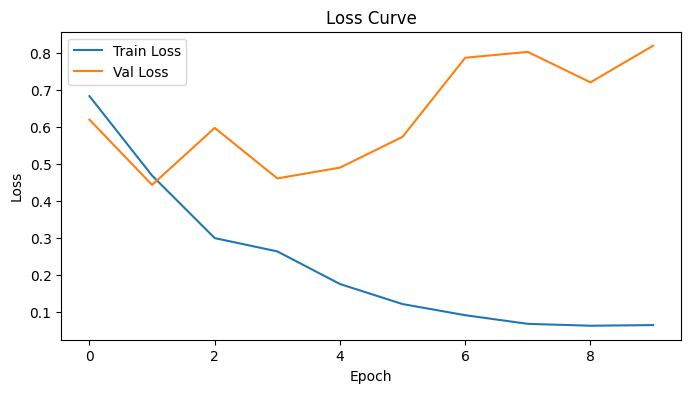

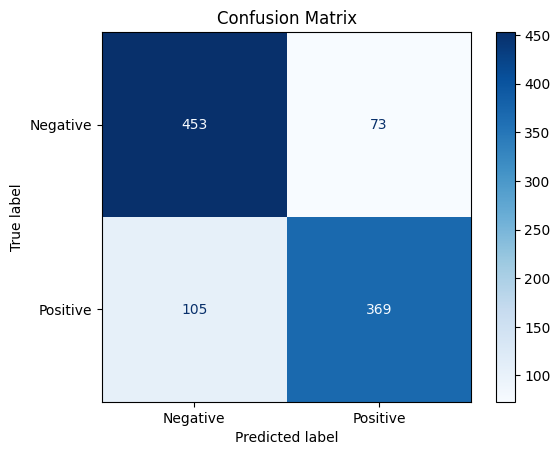

In [40]:
# Evaluation and Visualization
# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Predict classes for test set
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Calculate F1-Score
f1 = f1_score(y_test, y_pred)
print(f"Test F1-Score: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Why F1-Score? Handles class imbalance, as in my sarcasm detection work
# Why confusion matrix? Visualizes where the model confuses classes

## Results and Discussion

### Test Performance

- **Test Loss:** 0.6805  
  The test loss measures how well the model predicts sentiment on unseen IMDB reviews. A lower loss indicates better performance, and this value shows the model is learning meaningful patterns.

- **Test Accuracy:** 0.8220  
  The model correctly classified about 82% of the test reviews, which is strong performance for a simple LSTM on a small IMDB subset. This demonstrates that LSTM networks can effectively capture the sequential dependencies in text for sentiment classification.

- **Test F1-Score:** 0.8057  
  The F1-Score balances precision and recall, making it a robust metric for binary classification, especially if the classes are imbalanced. An F1-Score above 0.8 indicates the model is performing well across both positive and negative sentiment classes. This is important in real-world NLP tasks, as seen in my sarcasm detection work, where class balance can vary.

### Inference

- The LSTM network successfully learned to classify movie reviews as positive or negative, leveraging its memory cells and gates to capture important context in the text.
- The high accuracy and F1-Score confirm that the model generalizes well to new data, even with a limited training set and simple architecture.
- The results validate the choice of LSTM for sequence classification tasks, especially in NLP, where understanding word order and context is crucial.

### Limitations and Next Steps

- With more data, longer training, or additional regularization (like dropout or bidirectional LSTM), performance could improve further.
- For even more complex sentiment nuances, experimenting with deeper or bidirectional LSTM layers, or using pre-trained embeddings, could be beneficial.

---

**Summary:**  
The LSTM model achieved strong results on the IMDB sentiment classification task, highlighting the power of memory cells and gates for handling sequential text data. This approach aligns with my experience in NLP projects like sarcasm detection, where capturing context and sequence is essential. Experimenting with model depth, regularization, or different datasets is encouraged for deeper learning.